In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker
import seaborn as sns

# Global font: bold Times New Roman, larger size
plt.rcParams.update({
    'font.size': 20,
    'font.family': 'serif',
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.serif': ['Times New Roman']
})

plt.rcParams['figure.constrained_layout.use'] = True

# Load benchmark CSVs
csv_files = list(Path('../Benchmark/bench_results').rglob('bench_*.csv'))
if not csv_files:
    raise FileNotFoundError("No benchmark CSV files found. Make sure you're running from the project root.")
frames = []
for fp in csv_files:
    df = pd.read_csv(fp)
    df = df[~df['query'].str.startswith('preload_')]
    frames.append(df)
data = pd.concat(frames, ignore_index=True)
data['size'] = data['size'].astype(int)
data


,baseline,query,size,mean_ms,std_ms
0,preload,contactFull,1000,2.703962,0.064791
1,preload,contactProj,1000,1.559700,0.023107
2,preload,contactPred,1000,0.046363,0.009106
3,preload,photoFull,1000,2457.695875,106.554915
4,preload,photoProj,1000,2347.480450,37.660945
...,...,...,...,...,...
67,nopushdown,contactPred,1000,25.078613,0.738301
68,nopushdown,photoFull,1000,1384.063229,53.005583
69,nopushdown,photoProj,1000,1250.998883,45.606408
70,nopushdown,photoPred,1000,1217.461237,14.723236


In [2]:
def plot_group(queries, subplot_width=5, subplot_height=4):
    baselines = data['baseline'].unique()
    n = len(queries)
    figsize = (20, 4)

    fig, axes = plt.subplots(1, n, figsize=figsize, sharey=False)
    if n == 1:
        axes = [axes]

    is_loc_plot = queries[0].startswith('loc')
    baseline_colors = {b: c for b, c in zip(baselines, sns.color_palette())}

    for i, (ax, q) in enumerate(zip(axes, queries)):
        for baseline in baselines:
            d = data[(data['query'] == q) & (data['baseline'] == baseline)].sort_values('size')
            if is_loc_plot:
                d = d[d['size'] == 10000]
            if d.empty:
                continue

            # Calculate Standard Error of the Mean (SEM)
            sem = d['std_ms'] / np.sqrt(10)  # N=10 samples per benchmark run

            # Plot mean with SEM error bars instead of std dev band
            ax.errorbar(x=d['size'], y=d['mean_ms'], yerr=sem, label=baseline,
                        marker='o', markersize=8, capsize=5, color=baseline_colors[baseline], lw=2)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(q)
        ax.set_xlabel('')
        ax.set_ylabel('')

        if is_loc_plot:
            ax.set_xticks([])
        else:
            sizes_present = sorted(data[data['query'] == q]['size'].unique())
            ax.set_xticks(sizes_present)
            ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

        ax.tick_params(axis='x', which='major', labelsize=18)
        # The legend is now created from the errorbar plots
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, fontsize=18, borderpad=0.1)

    axes[0].set_ylabel('Runtime (ms)', fontweight='bold')

    if not is_loc_plot:
        fig.supxlabel('Data Size', y=-0.08, fontweight='bold')

    # fig.subplots_adjust(left=0.05, right=0.98, top=0.85, bottom=0.2, wspace=0.25)
    fig_name = f"figures/bench/{queries[0][:-4]}.pdf"
    plt.savefig(fig_name, bbox_inches='tight')
    plt.show()
    plt.close()


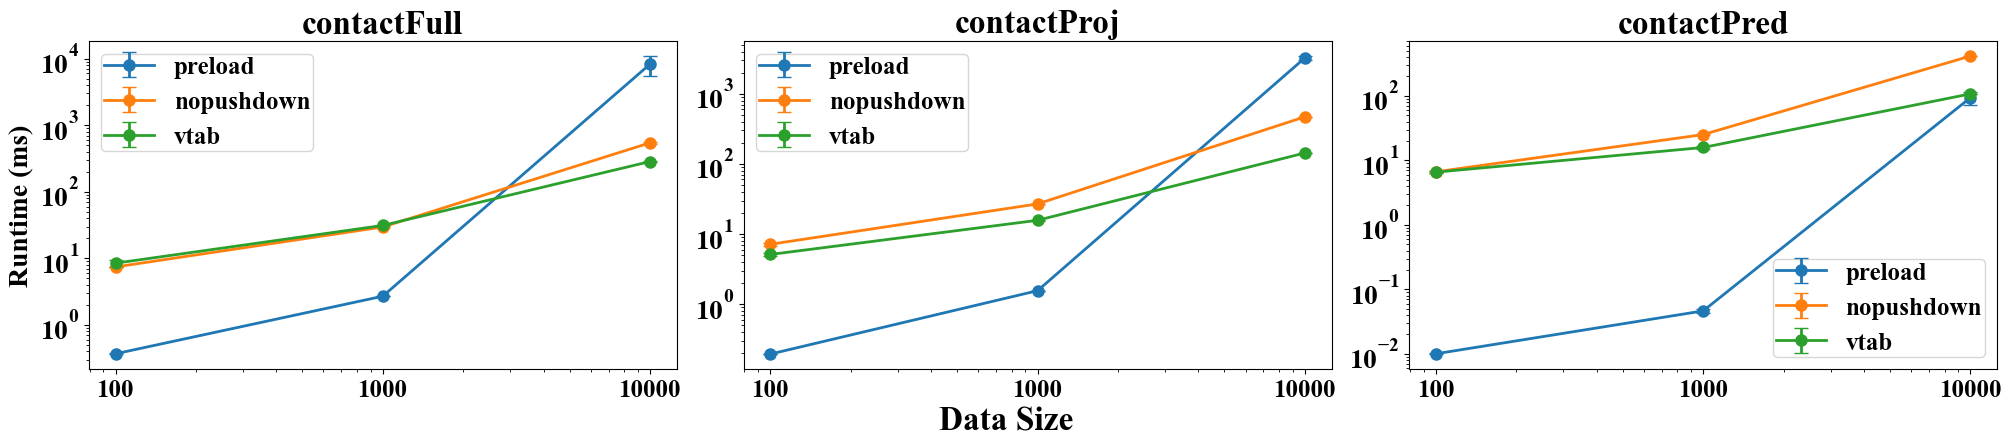

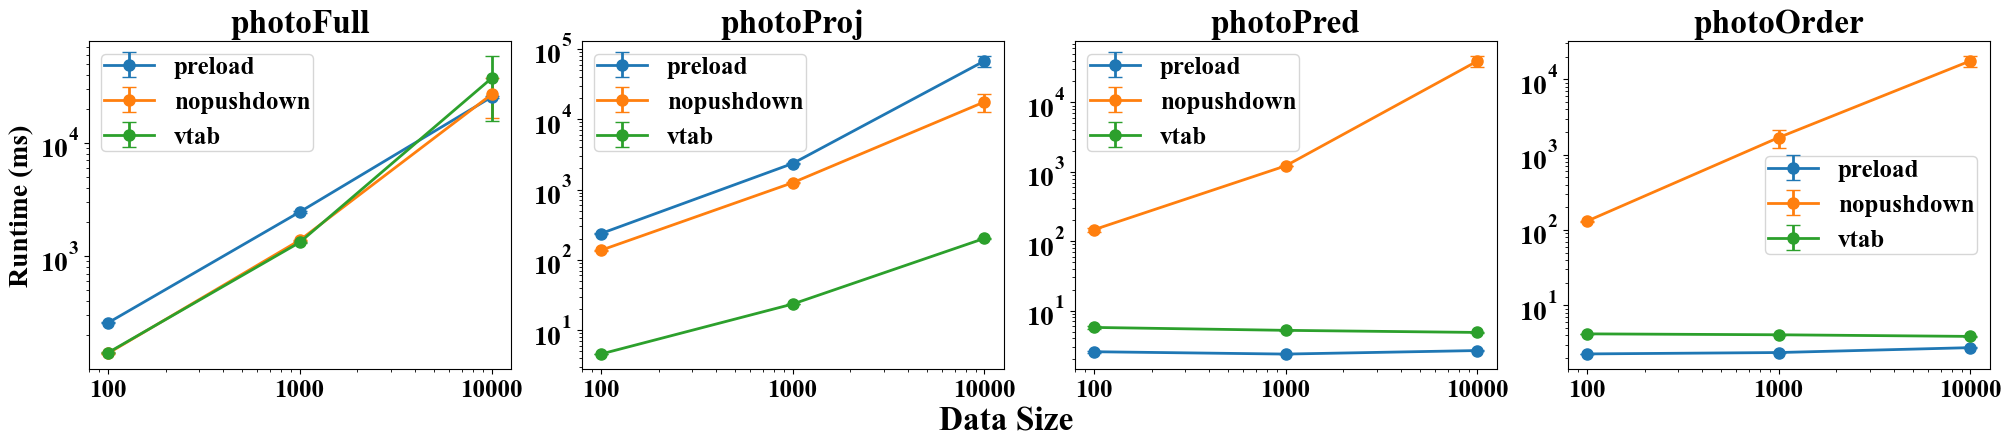

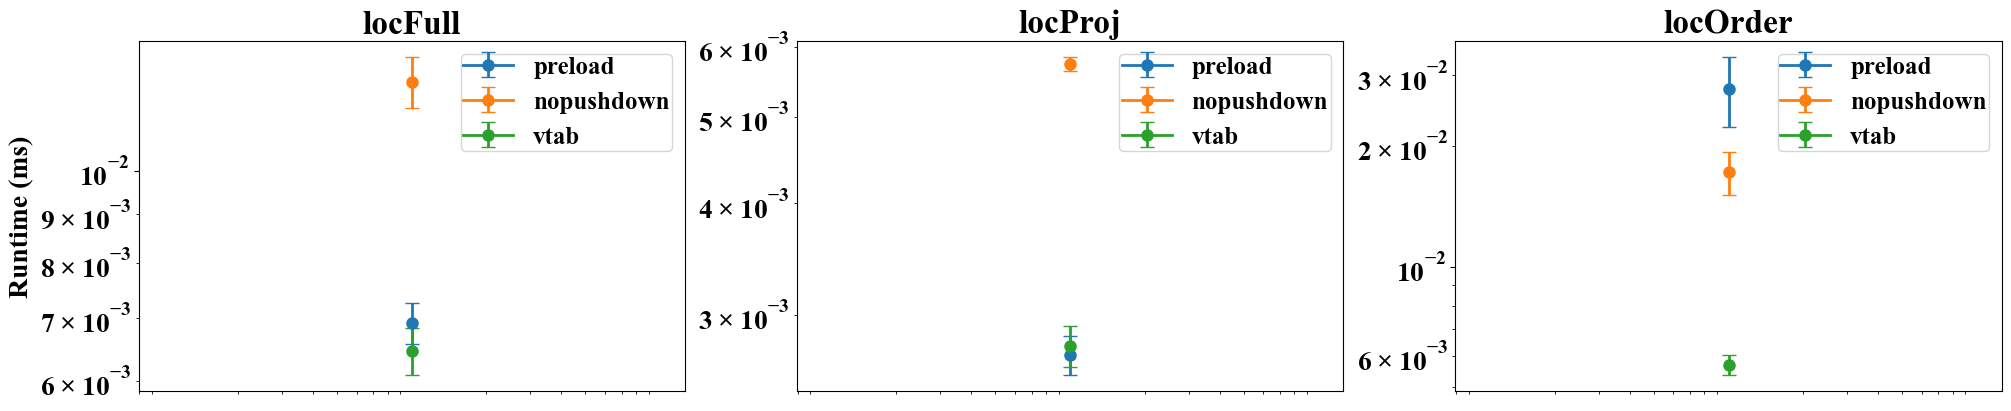

In [3]:
plot_group(['contactFull', 'contactProj', 'contactPred'])
# plt.savefig('figures/contact.png')
plot_group(['photoFull', 'photoProj', 'photoPred', 'photoOrder'])
# plt.savefig('figures/photo.png')
plot_group(['locFull', 'locProj', 'locOrder'])
# plt.savefig('figures/loc.png')
